In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('results/sbm_comparison.csv')

METHODS = ['s_gd2', 'TorusMDS', 'wrap_python']
COLORS  = {'s_gd2': '#4C72B0', 'TorusMDS': '#DD8452', 'wrap_python': '#55A868'}
METRICS = ['stress', 'np_score']
LABELS  = {
    'stress':     'Geodesic normalized stress',
    'distortion': 'Distortion',
    'sgs':        'SGS (Spearman rank corr.)',
    'np_score':   'Neighborhood preservation',
    't_embed':    'Embedding time (s)',
}

data = {m: df[df['method'] == m] for m in METHODS}
print('--- overall ---')
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'std']).round(4))
print('\n--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---')
print(df.groupby('method')['exp_idx'].nunique())


--- overall ---
             stress         np_score          t_embed         
               mean     std     mean     std     mean      std
method                                                        
TorusMDS     0.3375  0.0146   0.8873  0.1376   2.9424   5.5740
s_gd2        0.4105  0.0144   0.8860  0.1424   1.2851   3.3519
wrap_python  0.3964  0.0440   0.8638  0.1609  33.4075  87.6377

--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---
method
TorusMDS       436
s_gd2          436
wrap_python    414
Name: exp_idx, dtype: int64


## Violin plots

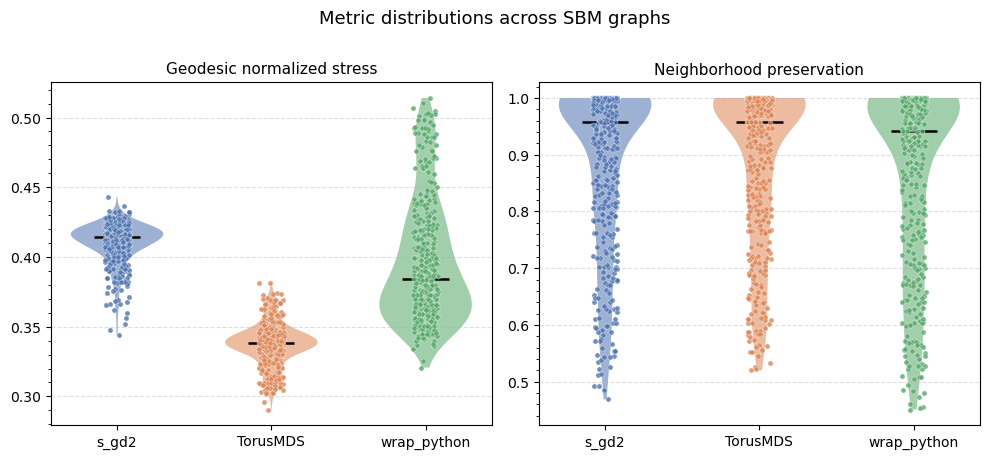

In [10]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].dropna().values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].dropna().values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=14, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.8)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)

fig.suptitle('Metric distributions across SBM graphs', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('./results/sbm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Metrics vs graph size n

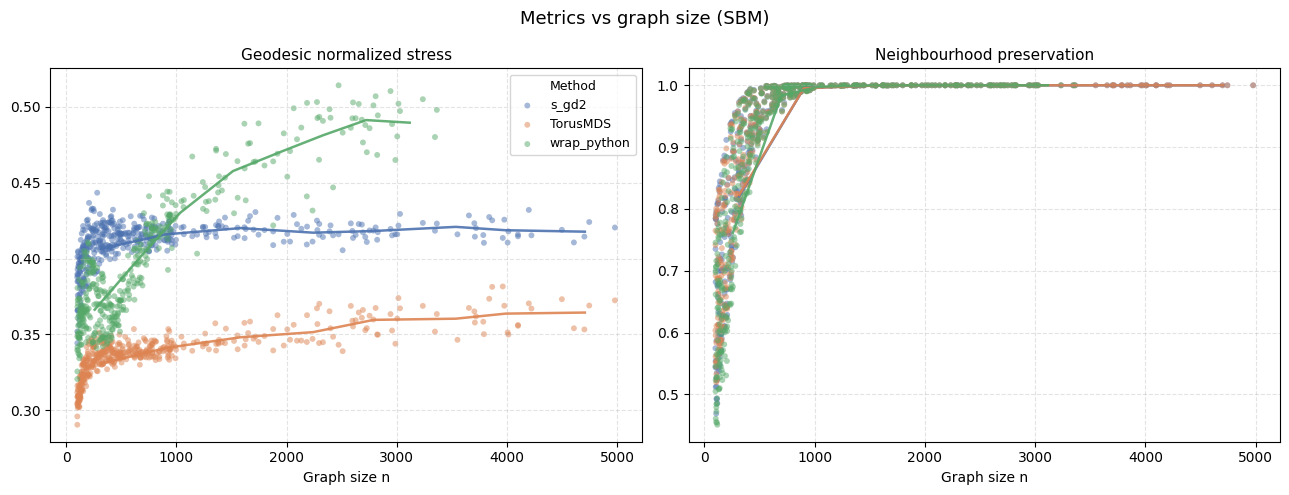

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=18, color=COLORS[m],
                   alpha=0.5, label=m, edgecolors='none')
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs graph size (SBM)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/sbm_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()


## Metrics vs number of blocks k

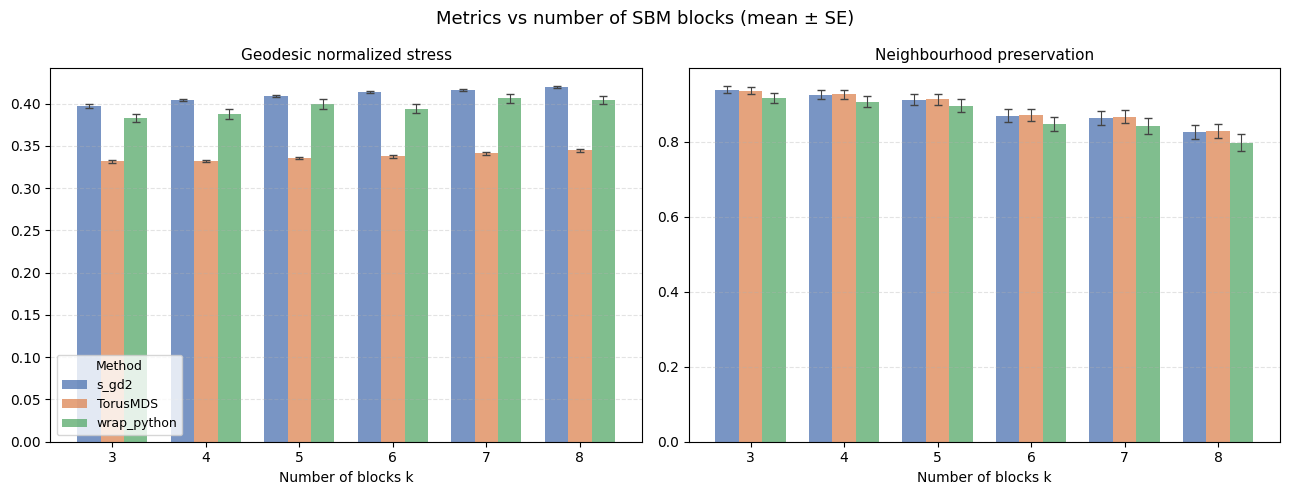

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
w = 0.25   # bar width
ks = sorted(df['k'].unique())

for ax, metric in zip(axes, METRICS):
    for xi, m in enumerate(METHODS):
        means = [data[m][data[m]['k'] == k][metric].mean() for k in ks]
        sems  = [data[m][data[m]['k'] == k][metric].sem()  for k in ks]
        offsets = np.array(ks) + (xi - (len(METHODS) - 1) / 2) * w
        ax.bar(offsets, means, width=w, color=COLORS[m],
               alpha=0.75, label=m, yerr=sems, capsize=3,
               error_kw=dict(elinewidth=0.8, ecolor='#444'))

    ax.set_xticks(ks)
    ax.set_xlabel('Number of blocks k', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

axes[0].legend(title='Method', fontsize=9, title_fontsize=9)
fig.suptitle('Metrics vs number of SBM blocks (mean ± SE)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/sbm_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()


## Running time distributions

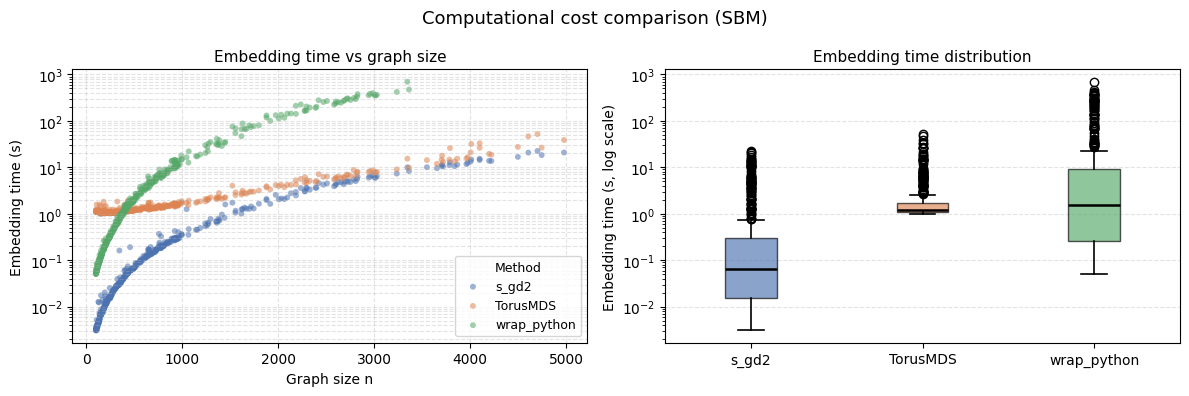

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=18, color=COLORS[m],
               alpha=0.55, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_yscale('log')
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=9, title_fontsize=9)
ax.grid(linestyle='--', alpha=0.35, which='both')

ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=10)
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison (SBM)', fontsize=13)
fig.tight_layout()
plt.savefig('./results/sbm_timing.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary table

In [6]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.round(4)
summary


,stress_mean,stress_median,stress_std,np_score_mean,np_score_median,np_score_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,
TorusMDS,0.3375,0.3383,0.0146,0.8873,0.9568,0.1376,2.9424,1.2164,5.5740
s_gd2,0.4105,0.4141,0.0144,0.8860,0.9576,0.1424,1.2851,0.0650,3.3519
wrap_python,0.3964,0.3841,0.0440,0.8638,0.9420,0.1609,33.4075,1.5630,87.6377
